# 05 外呼节奏描述性分析：外呼次数和转化是什么关系？（纯描述性，不做因果声称）

## 业务问题

1. 外呼次数（`campaign`：本次活动中打到第几次）和"是否办理定存"呈现什么**描述性关系**？
2. "黄金窗口"在哪：前几次触达捕获了多少比例的转化量？
3. 这个关系在**新客（first_time）与回归客（returning）**之间是否不同？

> **本 notebook 的定位（阶段表第五阶段）**：**仅描述性呈现，不做任何因果声称**。`campaign` 存在**反向因果（confounding by indication）**——打更多电话本身是"销售判断这个客户有希望"的**结果**，销售主观判断不可观测。00 文档声明四明确"对 campaign 不做 PSM"（04 已用 assert 把它挡在倾向得分模型之外），本 notebook 展示的是同一纪律的正面形态：**该描述的部分描述清楚，该闭嘴的地方闭嘴**。

## 口径与方法假设定义

### 分析对象与单位

- 每一行 = 一位客户本次活动的记录，`campaign` = **这位客户本次活动中累计被打到的次数**（1 ≤ campaign ≤ 56，中位数 2）；
- **无客户唯一 ID**（00 §2.1）：无法跨活动串联同一客户，本 notebook 只能描述"本次活动中打到第 k 次的客户的转化率"，**不能**重建"同一个客户被第 k 次触达时的响应"——后者需要纵向追踪数据，这是数据本身给不了的口径。

### 描述性指标的"可不可以说"界限

| 指标 | 能否计算 | 能说什么 | 不能说 |
|---|---|---|---|
| 转化率 × 次数 | ✅ | "打到第 k 次的客户，观测转化率为 x%"（条件事实） | "打第 k 次能提升 x"（后者是因果声称） |
| 前 k 次触达捕获的转化占比 | ✅ | "如果只打前 k 次就停止，本次活动的观测转化量中 k% 已被捕获"（累加事实） | "少打几次能省多少成本且不损失转化"（触达停止会影响后续转化，无法观测） |
| 相邻次数转化率差 | ✅ | "第 k 次与第 k-1 次客户的观测转化率相差 Δpp"（两个条件事实之差） | "每次拨打带来 Δpp 的边际收益" |

- **反向因果提示**：某客户被打了 10+ 次，往往不是"打了 10 次都失败"，而是**销售持续判断"有戏"**——高次数段甚至有转化率"回升/胶着"的形态，这是**选择效应（confounding by indication）**的典型外观，本 notebook 只标注、不解读为原因。

### 与全链路的口径一致性

- `campaign` 在 03 仅作**排序特征**（判别信号）、在 04 **不进倾向得分模型**（assert 自检）、在本 notebook **仅描述性呈现**——三处口径一致，未在任何一处被当作因果解释变量；
- 旅程分组沿用 `previous>0` 判定 returning（与 01/02/04 一致）。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# 定位项目根目录并加入模块搜索路径（与前序 notebook 相同的启动逻辑）
_CWD = Path.cwd()
_PROBE = Path("src") / "telemarketing_utils.py"
if not (_CWD / _PROBE).exists() and (_CWD.parent / _PROBE).exists():
    sys.path.insert(0, str(_CWD.parent))
else:
    sys.path.insert(0, str(_CWD))

from src.telemarketing_utils import find_project_root, setup_plot_style  # noqa: E402

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "bank-additional-full.csv"
REPORT_DIR = PROJECT_ROOT / "reports"

setup_plot_style()
import matplotlib.pyplot as plt  # noqa: E402

df = pd.read_csv(DATA_PATH, sep=";")
df["y_bin"] = (df["y"] == "yes").astype(int)
df["journey"] = np.where(df["previous"] == 0, "first_time", "returning")
print("总样本:", len(df), "| first_time:", int((df["journey"] == "first_time").sum()),
      "| returning:", int((df["journey"] == "returning").sum()))
print(f"campaign: min={df['campaign'].min()}, 中位数={df['campaign'].median()}, "
      f"均值={df['campaign'].mean():.2f}, max={df['campaign'].max()}")
print(f"campaign<=2 的客户占比: {100*(df['campaign'] <= 2).mean():.1f}%")

总样本: 41188 | first_time: 35563 | returning: 5625
campaign: min=1, 中位数=2.0, 均值=2.57, max=56
campaign<=2 的客户占比: 68.5%


In [2]:
# 转化率 × 次数（全量，1-9 次 + 10 次及以上合并显示；尾部样本小，仅呈现不解读）
MAX_K = 9
bins = list(range(1, MAX_K + 1))
df["camp_bin"] = pd.cut(df["campaign"], bins=[0] + bins + [df["campaign"].max() + 1],
                        labels=[str(i) for i in bins] + [f"{MAX_K}+"])
agg = df.groupby("camp_bin", observed=True).agg(
    n=("y_bin", "count"), conversions=("y_bin", "sum"), conv_rate=("y_bin", "mean"))
agg["conv_rate"] = (agg["conv_rate"] * 100).round(2)
agg["捕获转化占比%"] = (agg["conversions"] / df["y_bin"].sum() * 100).round(1)
agg["捕获转化占比_累计%"] = agg["捕获转化占比%"].cumsum().round(1)
print(agg.round(2).to_string())
print(f"\n（第 1 次触达客户的转化率 = {agg.loc['1','conv_rate']}%，"
      f"第 5 次 = {agg.loc['5','conv_rate']}%——前 5 次大体单调下降，5→6 次有轻微回升，9+ 段样本仅 {agg.loc['9+','n']} 条）")

              n  conversions  conv_rate  捕获转化占比%  捕获转化占比_累计%
camp_bin                                                    
1         17642         2300      13.04     49.6        49.6
2         10570         1211      11.46     26.1        75.7
3          5341          574      10.75     12.4        88.1
4          2651          249       9.39      5.4        93.5
5          1599          120       7.50      2.6        96.1
6           979           75       7.66      1.6        97.7
7           629           38       6.04      0.8        98.5
8           400           17       4.25      0.4        98.9
9           283           17       6.01      0.4        99.3
9+         1094           39       3.56      0.8       100.1

（第 1 次触达客户的转化率 = 13.04%，第 5 次 = 7.5%——前 5 次大体单调下降，5→6 次有轻微回升，9+ 段样本仅 1094 条）


In [3]:
# 相邻次数转化率差（两个条件事实之差，仅描述；Δ 不为"边际收益"）
sorted_c = df.sort_values("campaign")
rates = sorted_c.groupby("campaign")["y_bin"].agg(n="count", rate="mean")
rows = []
for k in range(2, 9):
    if k in rates.index and k - 1 in rates.index:
        rows.append({"次数段": f"{k-1}→{k}次", "前段转化率": round(rates.loc[k-1, "rate"], 4),
                     "后段转化率": round(rates.loc[k, "rate"], 4),
                     "Δ(pp)": round((rates.loc[k, "rate"] - rates.loc[k-1, "rate"]) * 100, 2),
                     "后段n": int(rates.loc[k, "n"])})
adj = pd.DataFrame(rows)
adj

,次数段,前段转化率,后段转化率,Δ(pp),后段n
0,1→2次,0.1304,0.1146,-1.58,10570
1,2→3次,0.1146,0.1075,-0.71,5341
2,3→4次,0.1075,0.0939,-1.35,2651
3,4→5次,0.0939,0.0750,-1.89,1599
4,5→6次,0.0750,0.0766,0.16,979
5,6→7次,0.0766,0.0604,-1.62,629
6,7→8次,0.0604,0.0425,-1.79,400


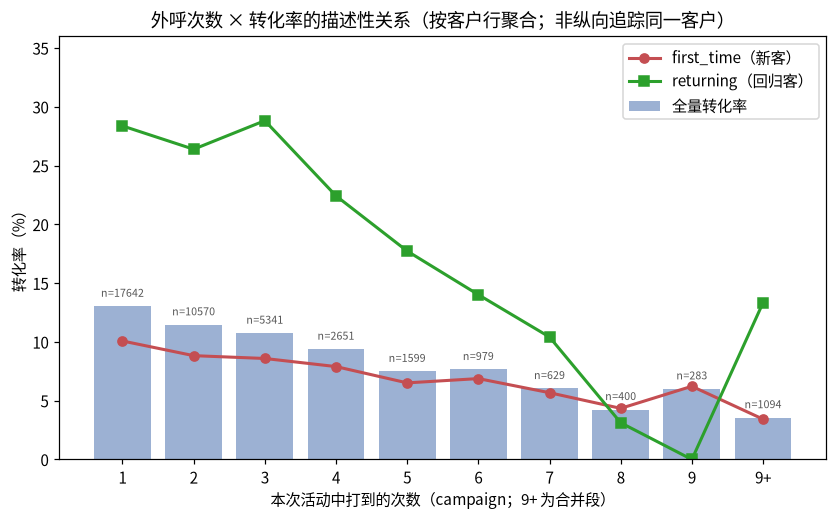

In [4]:
# 转化率 × 次数：全量 + 分旅程
bins_plot = [str(i) for i in range(1, MAX_K + 1)] + [f"{MAX_K}+"]
agg_ft = df[df["journey"] == "first_time"].groupby("camp_bin", observed=True)["y_bin"].mean() * 100
agg_rt = df[df["journey"] == "returning"].groupby("camp_bin", observed=True)["y_bin"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bins_plot))
ax.bar(x, agg["conv_rate"].values, color="#4C72B0", alpha=0.55, label="全量转化率")
ax.plot(x, agg_ft.values, "o-", color="#C44E52", lw=2, label="first_time（新客）")
ax.plot(x, agg_rt.values, "s-", color="#2CA02C", lw=2, label="returning（回归客）")
for xi, (k, row) in zip(x, agg.iterrows()):
    ax.text(xi, row["conv_rate"] + 0.8, f"n={int(row['n'])}", ha="center", fontsize=7, color="#555555")
ax.set_xticks(x, bins_plot)
ax.set_xlabel("本次活动中打到的次数（campaign；9+ 为合并段）")
ax.set_ylabel("转化率（%）")
ax.set_title("外呼次数 × 转化率的描述性关系（按客户行聚合；非纵向追踪同一客户）")
ax.set_ylim(0, max(agg_rt.max(), agg["conv_rate"].max()) * 1.25)
ax.legend()
plt.savefig(REPORT_DIR / "05_campaign_descriptive.png", bbox_inches="tight")
plt.show()

## "前几次是黄金窗口"吗？——先看捕获表，再看口径限制

**累计捕获占比**：按 campaign 次数累计的转化量占比（1 - 9+ 依次累加）。注意最后一列超过 88% 后仍在累加，要到 100% 才算全部转化被覆盖——这正好说明次数分布拖尾很长（max=56）。

前 1/2/3/5 次：覆盖客户 42.8/68.5/81.5%，捕获转化 49.6/75.7/88.1%


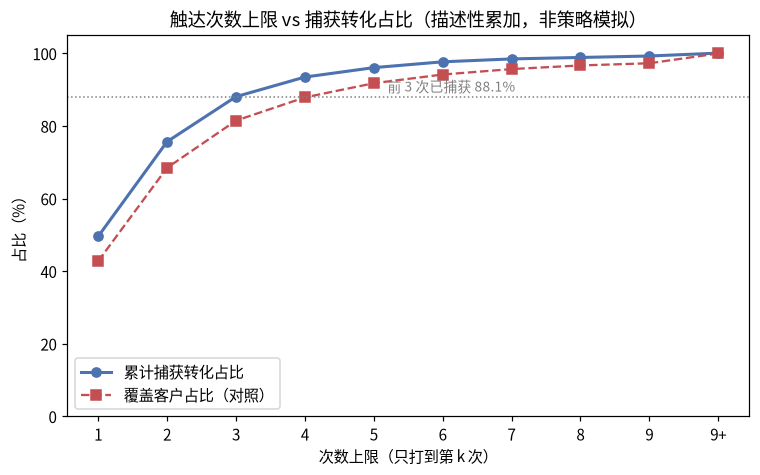

In [5]:
# 前 k 次触达捕获的转化占比（累加口径：只打前 k 次的观测转化量比例）
capture = pd.DataFrame({
    "打到第k次": agg.index,
    "覆盖客户占比%": (agg["n"] / len(df) * 100).cumsum().round(1),
    "累计捕获转化占比%": agg["捕获转化占比_累计%"],
})
print("前 1/2/3/5 次：覆盖客户 {}/{}/{}%，捕获转化 {}/{}/{}%".format(
    capture.loc["1", "覆盖客户占比%"], capture.loc["2", "覆盖客户占比%"], capture.loc["3", "覆盖客户占比%"],
    capture.loc["1", "累计捕获转化占比%"], capture.loc["2", "累计捕获转化占比%"], capture.loc["3", "累计捕获转化占比%"]))
capture.head(6)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(capture.index, capture["累计捕获转化占比%"], "o-", color="#4C72B0", lw=2, label="累计捕获转化占比")
ax.plot(capture.index, capture["覆盖客户占比%"], "s--", color="#C44E52", lw=1.5, label="覆盖客户占比（对照）")
ax.axhline(88.1, color="gray", ls=":", lw=1)
ax.text(4.2, 89.5, "前 3 次已捕获 88.1%", fontsize=9, color="gray")
ax.set_xlabel("次数上限（只打到第 k 次）")
ax.set_ylabel("占比（%）")
ax.set_title("触达次数上限 vs 捕获转化占比（描述性累加，非策略模拟）")
ax.set_ylim(0, 105)
ax.legend()
plt.savefig(REPORT_DIR / "05_campaign_capture.png", bbox_inches="tight")
plt.show()

In [6]:
# 分旅程：次数构成与转化（尾部段样本量小，仅呈现）
for grp in ["first_time", "returning"]:
    g = df[df["journey"] == grp]
    a = g.groupby("camp_bin", observed=True).agg(n=("y_bin", "count"), conv_rate=("y_bin", "mean"))
    a["conv_rate"] = (a["conv_rate"] * 100).round(2)
    print(f"[{grp}] n={len(g)}，总体转化率 {g['y_bin'].mean():.2%}")
    print(a[["n", "conv_rate"]].head(8).to_string())
    print()

[first_time] n=35563，总体转化率 8.83%
              n  conv_rate
camp_bin                  
1         14791      10.08
2          8990       8.83
3          4772       8.59
4          2379       7.90
5          1458       6.52
6           872       6.88
7           581       5.68
8           368       4.35

[returning] n=5625，总体转化率 26.65%
             n  conv_rate
camp_bin                 
1         2851      28.38
2         1580      26.39
3          569      28.82
4          272      22.43
5          141      17.73
6          107      14.02
7           48      10.42
8           32       3.12



## 局限声明与业务解读

### 局限声明（呼应 00 文档声明四与 §2.1）

1. **campaign 是反向因果变量（00 声明四）**：本 notebook 全部结论均为"条件事实"——"打到第 k 次的客户观测转化率是多少"，**不构成**"第 k 次拨打带来多少收益"。相邻次数差是**两组不同客户**的观测差，不是同一批客户从 k-1 打到 k 的变化；
2. **无客户唯一 ID（00 §2.1）**：无法区分"打到第 10 次"是高意向客户被持续跟进的痕迹，还是低转化客群的挣扎——两种机制都不能用本数据分辨，高次数段的任何形态都只能标注、不能归因；
3. **尾部样本量**：9+ 合并段全量仅 1,094 条（2.7%），returning 的 9+ 段仅 15 条——尾部数字噪声大，仅作位置参考，不作为任何结论的依据。

### 描述性事实总结

1. **转化高度集中在前几次触达**：全量下第 1 次触达客户 13.04%（17,642 人），且**第 1 次触达就捕获了 49.6% 的总转化量**；前 2 次 75.7%、前 3 次 **88.1%**——而覆盖客户占比同时只有 42.8% / 68.5% / 81.5%，**转化捕获始终领先于客户覆盖**；
2. **转化率随次数大体单调下降**：13.04% → 11.46% → 10.75% → 9.39% → 7.50%……第 1→5 次累计下降约 −5.5pp（13.04%→7.50%）；5→6 次出现 +0.16pp 的轻微回升（样本 979 条，属于选择效应的形态外观，**不做因果解读**），其后在 6.0%~7.7% 区间波动（6 次 7.66% / 7 次 6.04% / 8 次 4.25% / 9 次 6.01%），9+ 段 3.56%；
3. **分旅程的形态不同**：first_time 全程单调下滑（10.08% → 9+ 段 3.43%）；returning 前三次高位胶着（28.38% / 26.39% / 28.82%）后快速下滑（4 次 22.43%、5 次 17.73%）——回归客的"第几次触达"与其转化窗口直接相关，但同样只能描述；
4. **高次数段 ="销售很坚持"的选择效应形态**：6+ 次之后仍保持在 6%~8% 区间的现象，最合理的一致性解释是"被打了 N 次的客户是被销售持续判断为高意向的客户"——**这恰好是 04 为什么把 campaign 挡在 PSM 之外（confounding by indication）的正面证据**：一个与结果强相关、但因果方向由不可观测判断驱动的变量，只能描述到此为止。

### 与 01-04 的口径一致性（全链路呼应）

- `campaign` 在 03 = 排序特征（判别信号不解读为因果）、04 = assert 排除（不入倾向得分模型）、05 = 纯描述性——三处口径一致；
- 旅程分组（`previous>0`）与 01/02/04 一致；本 notebook 未出现任何"因果/效应/收益"措辞，全部为"条件事实 + 描述性差值"表述。